# Results figures

Reads the committed JSON files in `checkpoint/`. Nothing is recomputed and
nothing is written to disk; figures render inline only.

Three figures:

1. **Descriptor tiers** — the headline negative result. Four nested feature
   sets on two endpoints, with error bars across five clustered splits.
2. **Evaluation protocol** — the 2x2 over split type and censoring treatment,
   showing that the ceiling effect exceeds the leakage effect.
3. **Predictive heads** — held-out performance per endpoint against sample size.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CHECKPOINT = Path("../checkpoint")

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.5,
})

INK = "#2b2b2b"
ACCENT = "#4a6fa5"
MUTED = "#9aa5b1"
WARN = "#b5553d"


def load(name):
    path = CHECKPOINT / name
    if not path.exists():
        print(f"missing: {path}")
        return None
    return json.loads(path.read_text())

## 1. Descriptor tiers

The claim this figure supports: under homology-controlled evaluation, no family
of sequence-derived structural descriptor improves prediction over amino acid
composition. If the error bars overlap across all four tiers, the geometry adds
nothing that composition does not already carry.

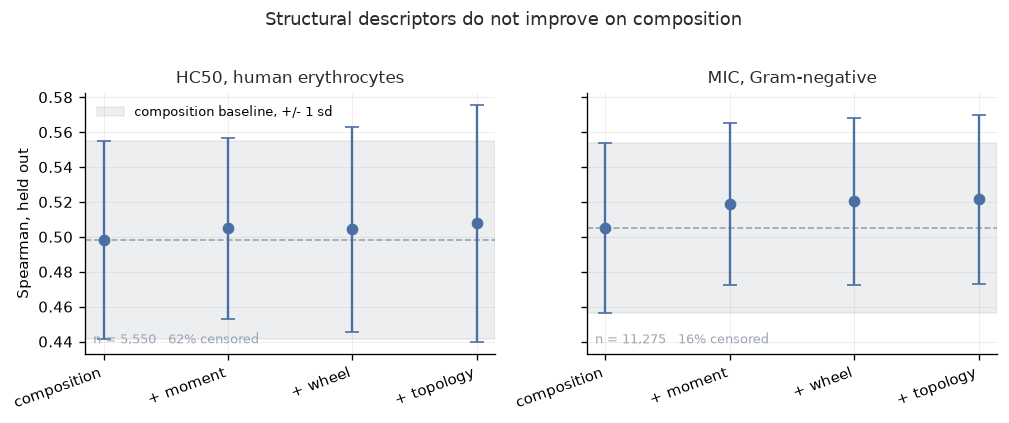

In [2]:
hc50 = load("ablation.json")
gramneg = load("ablation_gramneg.json")

TIERS = ["composition", "+moment", "+wheel", "+topology"]
LABELS = ["composition", "+ moment", "+ wheel", "+ topology"]


def tier_values(blob):
    means = [blob[t]["spearman_mean"] for t in TIERS if t in blob]
    stds = [blob[t]["spearman_std"] for t in TIERS if t in blob]
    return np.array(means), np.array(stds)


fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.4), sharey=True)
panels = [
    (hc50, "HC50, human erythrocytes", "n = 5,550   62% censored"),
    (gramneg, "MIC, Gram-negative", "n = 11,275   16% censored"),
]

for ax, (blob, title, subtitle) in zip(axes, panels):
    if blob is None:
        continue
    means, stds = tier_values(blob)
    x = np.arange(len(means))

    # The band shows one standard deviation around the composition baseline.
    # Any tier whose marker falls inside it is indistinguishable from using no
    # structural descriptor at all.
    ax.axhspan(means[0] - stds[0], means[0] + stds[0], color=MUTED, alpha=0.18,
               label="composition baseline, +/- 1 sd")
    ax.axhline(means[0], color=MUTED, lw=1, ls="--")

    ax.errorbar(x, means, yerr=stds, fmt="o", color=ACCENT, capsize=4,
                markersize=6, lw=1.4)
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS[:len(means)], rotation=20, ha="right")
    ax.set_title(title, fontsize=10, color=INK)
    ax.text(0.02, 0.04, subtitle, transform=ax.transAxes, fontsize=8, color=MUTED)

axes[0].set_ylabel("Spearman, held out")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle("Structural descriptors do not improve on composition",
             fontsize=11, color=INK, y=1.02)
plt.tight_layout()
plt.show()

## 2. Evaluation protocol

A two-by-two over split type and censoring treatment. The comparison of interest
is not only the total gap between the field's usual protocol and a controlled
one, but which of the two artifacts contributes more.

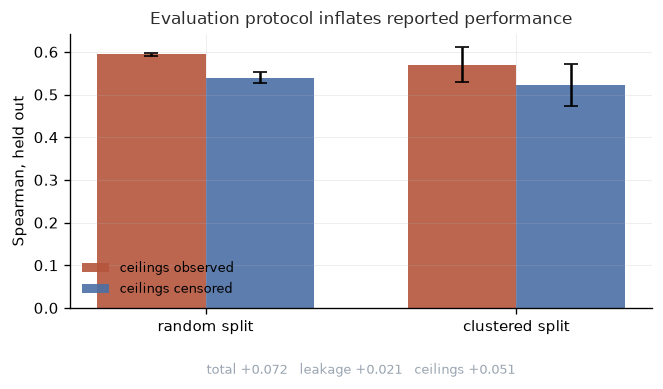

In [3]:
protocol = load("protocol_gram_negative.json") or load("protocol_hc50.json")

if protocol:
    order = [
        ("A random split, ceilings observed", "random", "observed"),
        ("B random split, ceilings censored", "random", "censored"),
        ("C clustered split, ceilings observed", "clustered", "observed"),
        ("D clustered split, ceilings censored", "clustered", "censored"),
    ]
    rows = [(s, c, protocol[k]["spearman_mean"], protocol[k]["spearman_std"])
            for k, s, c in order if k in protocol]

    fig, ax = plt.subplots(figsize=(5.6, 3.4))
    width = 0.35
    splits = ["random", "clustered"]
    censorings = ["observed", "censored"]
    colors = {"observed": WARN, "censored": ACCENT}

    for j, cens in enumerate(censorings):
        means = [m for s, c, m, _ in rows if c == cens]
        stds = [sd for s, c, _, sd in rows if c == cens]
        x = np.arange(len(means)) + (j - 0.5) * width
        ax.bar(x, means, width, yerr=stds, capsize=4, color=colors[cens],
               label=f"ceilings {cens}", alpha=0.9)

    ax.set_xticks(np.arange(len(splits)))
    ax.set_xticklabels([f"{s} split" for s in splits])
    ax.set_ylabel("Spearman, held out")
    ax.set_title("Evaluation protocol inflates reported performance",
                 fontsize=10, color=INK)
    ax.legend(frameon=False, fontsize=8)

    by_key = {k: protocol[k]["spearman_mean"] for k, _, _ in order if k in protocol}
    if len(by_key) == 4:
        a, b, c, d = (by_key[k] for k, _, _ in order)
        note = (f"total {a - d:+.3f}   "
                f"leakage {((a - c) + (b - d)) / 2:+.3f}   "
                f"ceilings {((a - b) + (c - d)) / 2:+.3f}")
        ax.text(0.5, -0.24, note, transform=ax.transAxes, ha="center",
                fontsize=8, color=MUTED)

    plt.tight_layout()
    plt.show()

## 3. Predictive heads

Held-out performance against training set size. The resistant head is visibly
underpowered, which is why it contributes a weighted shift to the potency axes
rather than forming an objective of its own.

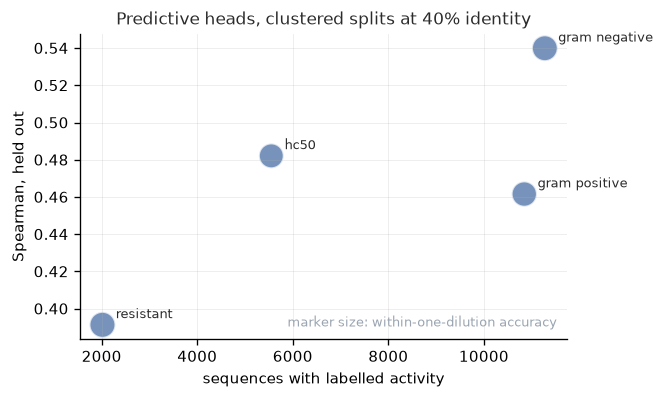

In [4]:
metrics = load("predictor_metrics.json")

if metrics:
    heads = [(k, v) for k, v in metrics.items() if isinstance(v, dict) and "spearman" in v]
    names = [k.replace("_", " ") for k, _ in heads]
    spearman = [v["spearman"] for _, v in heads]
    within = [v.get("within_one_dilution", np.nan) for _, v in heads]
    n = [v.get("n_train", 0) + v.get("n_test", 0) for _, v in heads]

    fig, ax = plt.subplots(figsize=(5.6, 3.4))
    scatter = ax.scatter(n, spearman, s=[80 + 400 * w for w in within],
                         color=ACCENT, alpha=0.75, edgecolor="white", lw=1.2)
    for xi, yi, label in zip(n, spearman, names):
        ax.annotate(label, (xi, yi), textcoords="offset points",
                    xytext=(8, 4), fontsize=8, color=INK)

    ax.set_xlabel("sequences with labelled activity")
    ax.set_ylabel("Spearman, held out")
    ax.set_title("Predictive heads, clustered splits at 40% identity",
                 fontsize=10, color=INK)
    ax.text(0.98, 0.04, "marker size: within-one-dilution accuracy",
            transform=ax.transAxes, ha="right", fontsize=8, color=MUTED)
    plt.tight_layout()
    plt.show()

## 4. The factorial draw pool

Where the selected peptides sit in the plane of the two contrast variables. Runs
only if `generate/design_report.json` is present.

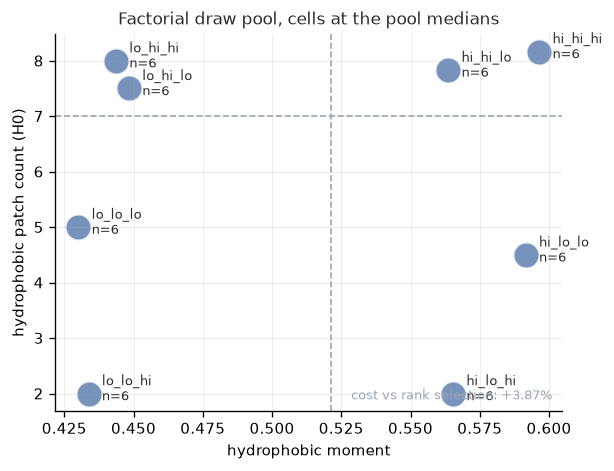

In [5]:
design_path = Path("../generate/design_report.json")

if design_path.exists():
    report = json.loads(design_path.read_text())
    cells = report.get("cells", {})
    thresholds = report.get("thresholds", {})

    fig, ax = plt.subplots(figsize=(5.2, 4.0))
    for name, m in sorted(cells.items()):
        x = m.get("mean_moment_helix")
        y = m.get("mean_h0_n_patches")
        if x is None or y is None:
            continue
        ax.scatter(x, y, s=60 + 30 * m["selected"], color=ACCENT, alpha=0.75,
                   edgecolor="white", lw=1.2)
        ax.annotate(f"{name}\nn={m['selected']}", (x, y),
                    textcoords="offset points", xytext=(8, -4), fontsize=7.5,
                    color=INK)

    if "moment_helix" in thresholds:
        ax.axvline(thresholds["moment_helix"], color=MUTED, ls="--", lw=1)
    if "h0_n_patches" in thresholds:
        ax.axhline(thresholds["h0_n_patches"], color=MUTED, ls="--", lw=1)

    ax.set_xlabel("hydrophobic moment")
    ax.set_ylabel("hydrophobic patch count (H0)")
    ax.set_title("Factorial draw pool, cells at the pool medians",
                 fontsize=10, color=INK)
    cost = report.get("relative_cost")
    if cost is not None:
        ax.text(0.98, 0.03, f"cost vs rank selection: {cost:+.2%}",
                transform=ax.transAxes, ha="right", fontsize=8, color=MUTED)
    plt.tight_layout()
    plt.show()
else:
    print("No design report. Run scripts/design_top.py to produce one.")